# A single excitation on a lattice

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien)

*Quantum Many-Body Simulation — Chapter 1 — Computational toolbox*

## 1. The model and its place in the course

This notebook assumes only notebook 00a, and specifically the part of it that built the three-point Laplacian on a ring and measured its
dispersion relation $\omega_{\rm FD}(k) = (1-\cos k\Delta x)/\Delta x^2$.

In 00a the grid was an approximation: the particle really lived on the continuous line, the $N_x$ samples stood in
for it, and the gap between the two was the discretisation error we spent most of the notebook measuring. Here we
invert that. The lattice is the physical system, with no continuum behind it. One excitation can sit on any of $N$
sites, so the state is a vector of $N$ amplitudes,

$$ \vert\psi\rangle = \sum_{j} c_j \vert j\rangle, $$

and the Hamiltonian lets it hop to a neighbour,

$$ \hat H = w \sum_j \big( \vert j\rangle\langle j+1\vert + \vert j+1\rangle\langle j\vert \big). $$

That is the whole model. It is an $N\times N$ matrix, so it costs nothing, and yet it has everything the many-body
chapters need: a band structure, a group velocity, a light cone, and two boundary conditions with different closed
forms.

It is exactly solvable twice over, by plane waves on a ring (Section 2) and by standing waves on an open chain
(Section 3), and both solutions are short enough to derive completely. Almost nothing in the many-body part of this
course has an exact solution at all.

It comes back. Notebook 03 (Sections 4.3 and 6.2) shows that the total magnetisation $\sum_j \hat Z_j$ commutes with the XX Hamiltonian, so
the number of reversed spins is conserved and the $2^N$-dimensional spectrum splits into magnetisation sectors. In the
sector with exactly one reversed spin, that Hamiltonian is the matrix of this notebook with $w = 2J$, and the same Bessel function
then describes a magnon. The Jordan-Wigner transformation, quoted in notebook 06, extends the statement from one
excitation to any number, making the XX chain a gas of free fermions on the same lattice.

It is the benchmark. Notebook 18 (MPS, DMRG and TEBD) builds approximations whose error has to be measured against
something known, and this is the only model in the course whose exact answer is available at chain lengths no state
vector can reach. Section 6 spells out why a one-excitation state is represented exactly at bond dimension two, which
is what makes such a comparison a test of the code rather than of the truncation.

The connection to notebook 00a is closer than an analogy. The three-point Laplacian there had $1/\Delta x^2$ on the
diagonal and $-1/2\Delta x^2$ beside it, so it is exactly the hopping matrix with $w = -1/2\Delta x^2$ plus a
constant, and a constant added to a Hamiltonian only multiplies the state by a global phase. The dispersion relation
we measured there as an *artefact* of the discretisation is the true band structure here.

The first cell builds the matrix. In code the sites are labelled $0,\dots,N-1$, so the open chain has the $N-1$ bonds
$j=0,\dots,N-2$, and the ring adds the two corner entries $H_{0,N-1}=H_{N-1,0}=w$. Throughout, $w=1$ (the variable `W`), so
every time is measured in units of $1/w$ (with $\hbar=1$). Besides NumPy the notebook needs two library functions:
`scipy.linalg.expm`, the matrix exponential that produces the numerically exact $e^{-i\hat Ht}$ we compare against, and
`scipy.special.jv(n, z)`, the Bessel function $J_n(z)$ introduced in Section 2.1.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels: enough for N<=26 (pure) / N<=13 (DM)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


In [2]:
import numpy as np
from scipy.linalg import expm
from scipy.special import jv
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True, linewidth=140)

def hop(N, periodic=False, w=1.0):
    """The hopping matrix: 0 on the diagonal, w on both off-diagonals, plus the wrap-around for a ring."""
    H = np.zeros((N, N))
    for j in range(N - 1):
        H[j, j + 1] = H[j + 1, j] = w
    if periodic:
        H[0, N - 1] = H[N - 1, 0] = w
    return H

W = 1.0
print(hop(5, periodic=False))
print("\nand as a ring:\n", hop(5, periodic=True))

[[0. 1. 0. 0. 0.]
 [1. 0. 1. 0. 0.]
 [0. 1. 0. 1. 0.]
 [0. 0. 1. 0. 1.]
 [0. 0. 0. 1. 0.]]

and as a ring:
 [[0. 1. 0. 0. 1.]
 [1. 0. 1. 0. 0.]
 [0. 1. 0. 1. 0.]
 [0. 0. 1. 0. 1.]
 [1. 0. 0. 1. 0.]]


## 2. The ring: plane waves and the band

On a ring of $N$ sites the model is invariant under $j \to j+1$, so the eigenvectors are plane waves. Put

$$ \vert k\rangle = \frac{1}{\sqrt N}\sum_j e^{ikj}\vert j\rangle, \qquad k = \frac{2\pi m}{N},\quad m=0,\dots,N-1, $$

where the allowed $k$ follow from requiring $e^{ik(j+N)} = e^{ikj}$. Since $k$ and $k+2\pi$ label the same state, the
range can equally be taken as $k\in(-\pi,\pi]$, which centres the band on $k=0$. Apply
$\hat H$: the term $\vert j+1\rangle\langle j\vert$ moves the amplitude at $j$ one site to the right, so relabelling
$j\to j-1$ in its sum turns $e^{ikj}$ into $e^{ik(j-1)}$, a factor $e^{-ik}$; the term $\vert j\rangle\langle j+1\vert$
moves it left and gives $e^{+ik}$ in the same way, so

$$ \hat H \vert k\rangle = w\big(e^{ik} + e^{-ik}\big)\vert k\rangle = \underbrace{2w\cos k}_{E_k}\,\vert k\rangle. $$

That is the *band*: a single cosine of width $4w$, running from $-2w$ at $k=\pi$ to $+2w$ at $k=0$.

In [3]:
N = 200
E = np.sort(np.linalg.eigvalsh(hop(N, periodic=True)))
k = 2 * np.pi * np.arange(N) / N
print(f"ring of {N} sites (the front has not reached the seam)")
print(f"  spectrum vs 2w cos k : max difference {np.abs(E - np.sort(2*W*np.cos(k))).max():.2e}")
print(f"  band edges           : {E[0]:+.6f} .. {E[-1]:+.6f}   (predicted {-2*W:+.1f} .. {+2*W:+.1f})")

ring of 200 sites (the front has not reached the seam)
  spectrum vs 2w cos k : max difference 2.89e-15
  band edges           : -2.000000 .. +2.000000   (predicted -2.0 .. +2.0)


### 2.1 The propagator and the Bessel functions

Start the excitation on one site, $c_j(0)=\delta_{j,0}$, and ask for the amplitude at site $n$ at time $t$. Expand
the initial state in plane waves and propagate each one by its own phase:

$$ G_n(t) = \langle n\vert e^{-i\hat Ht}\vert 0\rangle = \frac1N\sum_k e^{ikn}e^{-i2wt\cos k}
         \;\xrightarrow[N\to\infty]{}\; \int_{-\pi}^{\pi}\frac{dk}{2\pi}\, e^{ikn}\,e^{-i2wt\cos k}. $$

The integral is a standard one. The *Jacobi-Anger expansion* says

$$ e^{-iz\cos k} = \sum_{m=-\infty}^{\infty} (-i)^m J_m(z)\, e^{imk}, $$

with $J_m$ the Bessel function of the first kind. Insert it and use $\int \frac{dk}{2\pi}e^{i(n+m)k} = \delta_{n+m,0}$:

$$ G_n(t) = (-i)^{-n} J_{-n}(2wt) = i^n(-1)^n J_n(2wt) = (-i)^n J_n(2wt), $$

where the last step used $J_{-n} = (-1)^nJ_n$ and $i^n(-1)^n = (-i)^n$. So the density is

$$ \boxed{\;p_j(t) = \vert G_{j}(t)\vert^2 = J_{j}(2wt)^2\;} $$

which is the complete solution on an infinite chain. (The probability is called $p_j$ rather than $n_j$ so that it does not
collide with the site index $n$.) The matrix exponential below reproduces it.

In the cell the excitation starts in the middle of the ring, at site `N // 2` $=100$, so that its two fronts have 100
sites to travel before they meet at the seam, and `d` is the distance $n=j-100$ from the starting site. The prediction is
evaluated at $\vert n\vert$ because $G_{-n}=G_n$: with $J_{-n}=(-1)^nJ_n$ one has
$(-i)^{-n}J_{-n}=(-i)^{-n}(-1)^nJ_n=(-i)^nJ_n$, so the excitation spreads symmetrically to both sides.

In [4]:
N = 200
H = hop(N, periodic=True)
c0 = np.eye(N)[N // 2]
d = np.arange(N) - N // 2
print("propagator against (-i)^n J_n(2wt), ring of 200 sites (long enough to be 'infinite' here)")
for t in (0.5, 1.0, 2.0, 5.0, 10.0):
    G = expm(-1j * H * t) @ c0
    pred = (-1j) ** np.abs(d) * jv(np.abs(d), 2 * W * t)
    print(f"  t={t:5.1f}: max|G - (-i)^n J_n(2wt)| = {np.abs(G - pred).max():.2e}"
          f"   (front at |n| ~ 2wt = {2*W*t:.0f})")

propagator against (-i)^n J_n(2wt), ring of 200 sites (long enough to be 'infinite' here)
  t=  0.5: max|G - (-i)^n J_n(2wt)| = 1.67e-16   (front at |n| ~ 2wt = 1)


  t=  1.0: max|G - (-i)^n J_n(2wt)| = 2.22e-16   (front at |n| ~ 2wt = 2)


  t=  2.0: max|G - (-i)^n J_n(2wt)| = 2.78e-16   (front at |n| ~ 2wt = 4)
  t=  5.0: max|G - (-i)^n J_n(2wt)| = 7.22e-16   (front at |n| ~ 2wt = 10)


  t= 10.0: max|G - (-i)^n J_n(2wt)| = 9.44e-16   (front at |n| ~ 2wt = 20)


## 3. The open chain: hard walls and standing waves

Cut the ring. Now there is no translation invariance and plane waves are no longer eigenvectors — but sines are. The
hopping equation in the bulk reads

$$ E\,c_j = w\,(c_{j-1} + c_{j+1}), $$

and at the two ends the missing neighbour is equivalent to demanding $c_0 = 0$ and $c_{N+1} = 0$ for sites labelled
$j=1,\dots,N$. Both are satisfied by

$$ \phi^{(m)}_j = \sqrt{\frac{2}{N+1}}\,\sin(q_m j), \qquad q_m = \frac{m\pi}{N+1},\quad m=1,\dots,N, $$

since $\sin(q_m\cdot 0)=0$ automatically and $\sin(q_m(N+1)) = \sin(m\pi) = 0$ by the choice of $q_m$. Substituting
and using $\sin(q(j-1)) + \sin(q(j+1)) = 2\cos q\,\sin(qj)$ gives

$$ E_m = 2w\cos q_m . $$

The same band as on the ring, sampled at different momenta — $q_m = m\pi/(N+1)$ instead of $k = 2\pi m/N$. The
propagator follows by expanding in this basis:

$$ G^{(N)}_{j,s}(t) = \sum_{m=1}^{N}\phi^{(m)}_j\phi^{(m)}_s e^{-iE_mt}
  = \frac{2}{N+1}\sum_{m=1}^{N}\sin(q_mj)\,\sin(q_ms)\,e^{-2iwt\cos q_m}. $$

This is exact for every $N$ and every $t$ — with no infinite-chain limit taken. It is the form to use when the
excitation starts near an edge.

The function below labels the sites $1,\dots,N$, as in the formula, whereas `hop` and NumPy arrays count from $0$; the
numerical initial state for a start on site $s$ is therefore the row `np.eye(N)[s - 1]`, and the comparison is made for an
excitation released from the edge site $s=1$.

In [5]:
def obc_propagator(N, s, t, w=1.0):
    """G^(N)_{j,s}(t) on an open chain of N sites, from the standing-wave basis.

    Exact at every N and every t: a sum of N terms, no matrix and no infinite-chain limit.
    Sites are labelled j = 1..N, and `s` is the site the excitation starts on.
    """
    q = np.pi * np.arange(1, N + 1) / (N + 1)              # the allowed momenta, q_m = m pi/(N+1)
    j = np.arange(1, N + 1)[:, None]                       # column of target sites
    phi_j = np.sin(q * j)                                  # sin(q_m j),  shape (N sites, N modes)
    phi_s = np.sin(q * s)                                  # sin(q_m s),  the source
    phase = np.exp(-2j * w * t * np.cos(q))                # e^{-i E_m t} with E_m = 2w cos q_m
    return (2 / (N + 1)) * (phi_j * phi_s * phase).sum(axis=1)


for N in (12, 40):
    H = hop(N, periodic=False)
    q = np.pi * np.arange(1, N + 1) / (N + 1)
    E = np.sort(np.linalg.eigvalsh(H))
    print(f"open chain, N={N}")
    print(f"  spectrum vs 2w cos q_m: max difference {np.abs(E - np.sort(2*W*np.cos(q))).max():.2e}")
    s = 1                                              # the excitation starts on the EDGE site
    for t in (0.5, 1.0, 2.0, 4.0):
        Gnum = expm(-1j * H * t) @ np.eye(N)[s - 1]
        Gana = obc_propagator(N, s, t, W)
        print(f"    t={t:4.1f}: max|numeric - standing-wave form| = {np.abs(Gnum - Gana).max():.2e}")

open chain, N=12
  spectrum vs 2w cos q_m: max difference 1.11e-15
    t= 0.5: max|numeric - standing-wave form| = 5.45e-16
    t= 1.0: max|numeric - standing-wave form| = 4.92e-16
    t= 2.0: max|numeric - standing-wave form| = 6.91e-16
    t= 4.0: max|numeric - standing-wave form| = 7.09e-16
open chain, N=40
  spectrum vs 2w cos q_m: max difference 1.75e-15
    t= 0.5: max|numeric - standing-wave form| = 1.04e-15
    t= 1.0: max|numeric - standing-wave form| = 1.25e-15
    t= 2.0: max|numeric - standing-wave form| = 1.26e-15
    t= 4.0: max|numeric - standing-wave form| = 1.07e-15


### 3.1 An excitation released at the wall: the method of images

How long does the infinite-chain result of Section 2.1 survive on a finite chain? The natural guess is: until the front reaches a
wall. For a release in the middle of the chain the guess is right, and the first cell below confirms it. For a release
on the edge site the guess fails, and it fails at $t=0^+$, because the excitation starts immediately next to a wall and
so has never been free of one. Getting this wrong would make any benchmark that starts an excitation at the end of a
chain fail for a reason that has nothing to do with the code being tested.

What replaces the free result is the *method of images*, the device used for a charge in front of a conducting plane.
The boundary condition $c_0 = 0$ is enforced on the infinite chain by adding a second source of opposite sign at the
mirror site $j = -1$; the two contributions then cancel at $j = 0$ by antisymmetry, for all time. Superposing the two
infinite-chain propagators,

$$ G_{j,1}(t) = G_{j-1}(t) - G_{j+1}(t) = (-i)^{j-1}\big[J_{j-1}(2wt) + J_{j+1}(2wt)\big], $$

where the bracket carries a plus sign because the two prefactors differ by $(-i)^2 = -1$, which cancels the minus of
the image. The Bessel recurrence $J_{n-1}(z) + J_{n+1}(z) = (2n/z)J_n(z)$ collapses the bracket to a single term, so
with $z = 2wt$

$$ G_{j,1}(t) = (-i)^{j-1}\,\frac{j}{wt}\,J_j(2wt), \qquad p_j(t) = \Big(\frac{j}{wt}\Big)^2 J_j(2wt)^2. $$

The factor $(j/wt)^2$ is the whole content of the wall. It suppresses the density near $j=0$, where the reflected
amplitude interferes destructively with the incident one, and tends to 1 far behind the front, where the wall is
irrelevant. Being exact on a semi-infinite chain, the image form holds on $N$ sites until the far wall is reached, near
$t=(N-1)/2w$.

In the cell, `jj` holds the site labels $1,\dots,40$. The mid-chain start is site $s=20$, which is the array row
`np.eye(N)[19]`, and its free prediction is $J_{\vert j-20\vert}(2wt)^2$. The edge start is site $s=1$, the row
`np.eye(N)[0]`; its free prediction, the infinite chain with no wall, is $J_{j-1}(2wt)^2$, and the image form is the
formula just derived.

In [6]:
N = 40
H = hop(N, periodic=False)
jj = np.arange(1, N + 1)

print("MID-chain release, s=20 of 40: the free (no-wall) form holds until the nearest wall")
c0 = np.eye(N)[19]
for t in (1.0, 4.0, 6.0, 9.0, 12.0):
    p_num = np.abs(expm(-1j * H * t) @ c0) ** 2
    p_free = jv(np.abs(jj - 20), 2 * W * t) ** 2
    print(f"  t={t:5.1f}: max|numeric - free| = {np.abs(p_num-p_free).max():.2e}"
          f"   (nearest wall reached at t=(s-1)/2w={19/(2*W):.1f})")

print("\nEDGE release, s=1: the free form fails at once; the image form is exact")
c0 = np.eye(N)[0]
for t in (1.0, 2.0, 4.0, 9.0, 15.0):
    p_num  = np.abs(expm(-1j * H * t) @ c0) ** 2
    p_img  = (jj / (W * t)) ** 2 * jv(jj, 2 * W * t) ** 2          # the image form
    p_free = jv(jj - 1, 2 * W * t) ** 2                            # the infinite chain, i.e. no wall
    print(f"  t={t:5.1f}: max|numeric - image| = {np.abs(p_num-p_img).max():.2e}"
          f"   max|numeric - free| = {np.abs(p_num-p_free).max():.2e}")
print(f"  the image form fails only past the FAR wall at t=(N-1)/2w={(N-1)/(2*W):.1f}")

MID-chain release, s=20 of 40: the free (no-wall) form holds until the nearest wall
  t=  1.0: max|numeric - free| = 2.78e-16   (nearest wall reached at t=(s-1)/2w=9.5)
  t=  4.0: max|numeric - free| = 8.38e-14   (nearest wall reached at t=(s-1)/2w=9.5)
  t=  6.0: max|numeric - free| = 1.25e-07   (nearest wall reached at t=(s-1)/2w=9.5)
  t=  9.0: max|numeric - free| = 9.67e-03   (nearest wall reached at t=(s-1)/2w=9.5)
  t= 12.0: max|numeric - free| = 1.31e-01   (nearest wall reached at t=(s-1)/2w=9.5)

EDGE release, s=1: the free form fails at once; the image form is exact
  t=  1.0: max|numeric - image| = 2.78e-16   max|numeric - free| = 2.82e-01
  t=  2.0: max|numeric - image| = 3.89e-16   max|numeric - free| = 2.84e-01
  t=  4.0: max|numeric - image| = 2.22e-16   max|numeric - free| = 2.22e-01
  t=  9.0: max|numeric - image| = 5.00e-16   max|numeric - free| = 1.60e-01
  t= 15.0: max|numeric - image| = 3.84e-07   max|numeric - free| = 1.20e-01
  the image form fails only past the F

## 4. The light cone

The band gives the speed. A wave packet built from momenta near $k$ travels at the group velocity

$$ v_g(k) = \frac{dE_k}{dk} = -2w\sin k, \qquad \max_k \vert v_g\vert = 2w, $$

so nothing moves faster than $2w$ and the excitation is confined to a *light cone* $\vert j\vert \lesssim 2wt$.
The Bessel function says the same thing more sharply: $J_n(z)$ is exponentially small for $z<n$, so site $n$ is
simply not reached before $t\approx n/(2w)$.

The density at site $n$ peaks later than the arrival time $n/(2w)$, at the *Airy edge*

$$ z_{\rm peak} \approx n + 0.81\,n^{1/3}, $$

which is the first maximum of $J_n$. The front is a sharp edge with an Airy-function profile: the density at a fixed
site rises abruptly as the edge passes, peaks just after, then oscillates while decaying.

### 4.1 Where the light cone and the constant 0.81 come from: stationary phase

Both statements follow from the integral of Section 2.1 by the *method of stationary phase*. Write its integrand as
$e^{i\varphi(k)}$ with

$$ \varphi(k) = nk - z\cos k, \qquad z = 2wt . \tag{A} $$

When $n$ and $z$ are large, $\varphi$ runs through many multiples of $2\pi$ across $(-\pi,\pi]$, and the contributions
of neighbouring $k$ cancel, except near the points where the phase is momentarily constant,

$$ \varphi'(k_s) = n + z\sin k_s = 0, \qquad\text{i.e.}\qquad \sin k_s = -\frac nz . \tag{B} $$

Condition (B) reads $v_g(k_s) = -2w\sin k_s = n/t$: the only plane waves that contribute at site $n$ at time $t$ are
those whose group velocity carries them there. For $z>n$ there are two such points, $k_s$ and $-\pi-k_s$, with
$\varphi''(k_s) = z\cos k_s = \pm\sqrt{z^2-n^2}$. Near each, $\varphi \simeq \varphi(k_s) + \tfrac12\varphi''(k_s)(k-k_s)^2$,
and the Gaussian integral $\int e^{-au^2}du = \sqrt{\pi/a}$ of notebook 00a, taken at $a = \mp i\varphi''/2$ (the limit
$\mathrm{Re}\,a\to0^+$), gives each a contribution of modulus $(2\pi\vert\varphi''\vert)^{-1/2}$, so that
$\vert J_n(z)\vert \lesssim 2\,(2\pi)^{-1/2}(z^2-n^2)^{-1/4}$ behind the front; at $n=0$ this is the familiar
$\sqrt{2/\pi z}$. For $z<n$ equation (B) has no real solution, the cancellation is complete up to exponentially small
terms, and that is the light cone.

At $z=n$ the two stationary points merge at $k=-\pi/2$, where $\varphi''=0$, and the quadratic expansion fails; the
cubic term is needed. Put $k=-\pi/2+q$, so that $\cos k = \sin q \simeq q - q^3/6$ and

$$ \varphi \simeq -\frac{n\pi}{2} + (n-z)\,q + \frac{z}{6}\,q^3 . \tag{C} $$

The integral is now dominated by small $q$, so its limits can be moved to $\pm\infty$. Substituting
$q=(2/z)^{1/3}s$ makes the cubic term $s^3/3$, and with $e^{-in\pi/2}=(-i)^n$

$$ G_n(t) \simeq (-i)^n\Big(\frac2z\Big)^{1/3}\int_{-\infty}^{\infty}\frac{ds}{2\pi}\,e^{i(s^3/3+xs)},
   \qquad x = (n-z)\Big(\frac2z\Big)^{1/3} . \tag{D} $$

The remaining integral is the definition of the *Airy function* $\mathrm{Ai}(x)$, so near the front

$$ J_n(z) \simeq \Big(\frac2z\Big)^{1/3}\,\mathrm{Ai}\Big((n-z)\Big(\frac2z\Big)^{1/3}\Big) . \tag{E} $$

$\mathrm{Ai}(x)$ decays as $e^{-\frac23x^{3/2}}$ for $x>0$ (ahead of the front) and oscillates for $x<0$ (behind it). Its
largest value is its first maximum, at the first zero of $\mathrm{Ai}'$, $a_1' = -1.018793$ (a tabulated number,
`scipy.special.ai_zeros`). Setting $x=a_1'$ and $z\simeq n$ in the slowly varying factor $(2/z)^{1/3}$ gives

$$ z_{\rm peak} \simeq n + \vert a_1'\vert\Big(\frac n2\Big)^{1/3} = n + 0.8086\,n^{1/3} , \tag{F} $$

the Airy edge quoted above. The second cell below checks (E) and (F) against the Bessel function.

In [7]:
print(f"max |v_g| = max |2w sin k| = {np.abs(2*W*np.sin(np.linspace(0,np.pi,200001))).max():.6f}  = 2w = {2*W}")
print("\narrival time against the measured peak of the density at site n")
tt = np.linspace(0, 40, 40001)
for n in (5, 10, 20, 40):
    t_peak = tt[(jv(n, 2 * W * tt) ** 2).argmax()]
    print(f"  n={n:2d}: arrival n/(2w) = {n/(2*W):5.1f};  peak at t = {t_peak:6.3f}, i.e. z = {2*W*t_peak:6.3f}"
          f"   against n + 0.81 n^(1/3) = {n + 0.81*n**(1/3):6.3f}")

max |v_g| = max |2w sin k| = 2.000000  = 2w = 2.0

arrival time against the measured peak of the density at site n


  n= 5: arrival n/(2w) =   2.5;  peak at t =  3.208, i.e. z =  6.416   against n + 0.81 n^(1/3) =  6.385


  n=10: arrival n/(2w) =   5.0;  peak at t =  5.885, i.e. z = 11.770   against n + 0.81 n^(1/3) = 11.745


  n=20: arrival n/(2w) =  10.0;  peak at t = 11.110, i.e. z = 22.220   against n + 0.81 n^(1/3) = 22.199


  n=40: arrival n/(2w) =  20.0;  peak at t = 21.393, i.e. z = 42.786   against n + 0.81 n^(1/3) = 42.770


In [8]:
from scipy.special import airy, ai_zeros

a1p = ai_zeros(1)[1][0]                                    # first zero of Ai', a_1' = -1.018793
print(f"a_1' = {a1p:.6f}  ->  |a_1'| / 2^(1/3) = {-a1p / 2**(1/3):.6f}   (the constant of Eq. (F))")
print("\nthe Airy form (E) against J_n(z) near the front, |z - n| < n^(1/3)")
for n in (10, 20, 40):
    z = np.linspace(n - n ** (1 / 3), n + n ** (1 / 3), 2001)
    airy_form = (2 / z) ** (1 / 3) * airy((n - z) * (2 / z) ** (1 / 3))[0]
    z_fine = np.linspace(n, n + 3 * n ** (1 / 3), 200001)
    print(f"  n={n:2d}: max|J_n - Airy form| = {np.abs(jv(n, z) - airy_form).max():.1e}   (max J_n = {jv(n, z).max():.3f});"
          f"  peak of J_n at z = {z_fine[jv(n, z_fine).argmax()]:.3f}, Eq. (F) gives {n - a1p * (n / 2) ** (1 / 3):.3f}")

a_1' = -1.018793  ->  |a_1'| / 2^(1/3) = 0.808617   (the constant of Eq. (F))

the Airy form (E) against J_n(z) near the front, |z - n| < n^(1/3)


  n=10: max|J_n - Airy form| = 6.9e-03   (max J_n = 0.303);  peak of J_n at z = 11.771, Eq. (F) gives 11.742


  n=20: max|J_n - Airy form| = 3.6e-03   (max J_n = 0.243);  peak of J_n at z = 22.219, Eq. (F) gives 22.195


  n=40: max|J_n - Airy form| = 1.9e-03   (max J_n = 0.195);  peak of J_n at z = 42.785, Eq. (F) gives 42.765


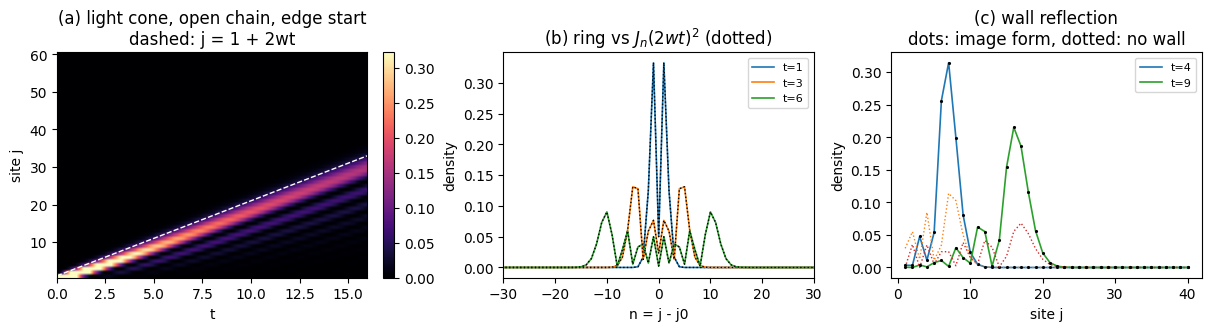

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.2), constrained_layout=True)

N, T = 60, 16.0
ts = np.linspace(0, T, 260)
H = hop(N, periodic=False)
dens = np.array([np.abs(expm(-1j * H * t) @ np.eye(N)[0]) ** 2 for t in ts])
im = ax[0].imshow(dens.T, origin="lower", aspect="auto", cmap="magma",
                  extent=[0, T, 0.5, N + 0.5], vmax=np.percentile(dens, 99.5))
ax[0].plot(ts, 1 + 2 * W * ts, "--", color="white", lw=1.0)
ax[0].set_ylim(0.5, N + 0.5); ax[0].set_xlabel("t"); ax[0].set_ylabel("site j")
ax[0].set_title("(a) light cone, open chain, edge start\ndashed: j = 1 + 2wt")
fig.colorbar(im, ax=ax[0])

N = 200; H = hop(N, periodic=True); c0 = np.eye(N)[N // 2]; d = np.arange(N) - N // 2
for t in (1.0, 3.0, 6.0):
    ax[1].plot(d, np.abs(expm(-1j * H * t) @ c0) ** 2, "-", lw=1.2, label=f"t={t:g}")
    ax[1].plot(d, jv(np.abs(d), 2 * W * t) ** 2, ":", color="black", lw=1.0)
ax[1].set_xlim(-30, 30); ax[1].set_xlabel("n = j - j0"); ax[1].set_ylabel("density")
ax[1].set_title("(b) ring vs $J_n(2wt)^2$ (dotted)"); ax[1].legend(fontsize=8)

N = 40; H = hop(N, periodic=False)
for t in (4.0, 9.0):
    ax[2].plot(np.arange(1, N + 1), np.abs(expm(-1j * H * t) @ np.eye(N)[0]) ** 2, "-", lw=1.2, label=f"t={t:g}")
    ax[2].plot(np.arange(1, N + 1), jv(np.arange(0, N), 2 * W * t) ** 2, ":", lw=1.0)
    jj_c = np.arange(1, N + 1)
    ax[2].plot(jj_c, (jj_c / (W * t)) ** 2 * jv(jj_c, 2 * W * t) ** 2, ".", color="black", ms=2.5)   # image form
ax[2].set_xlabel("site j"); ax[2].set_ylabel("density")
ax[2].set_title("(c) wall reflection\ndots: image form, dotted: no wall"); ax[2].legend(fontsize=8)
plt.show()

Panel (a) is the light cone. The excitation starts on the edge site $j=1$ of a 60-site chain and its front follows the
dashed line $j=1+2wt$, the maximal group velocity $2w$; behind the front the density oscillates, the decaying tail
described in Section 4. The front reaches the far end near $t=(N-1)/2w=29.5$, outside the time window $t\le16$ shown,
so no reflection is seen. Panel (b) cuts through the ring at three times: the computed density (solid) lies on
$J_n(2wt)^2$ (dotted), with the largest weight just inside the edge $\vert n\vert\approx2wt$ and almost nothing beyond it. Panel (c) is the edge start
of Section 3.1 on 40 sites: the dotted curves are the infinite-chain form $J_{j-1}(2wt)^2$, which ignores the wall and
misses the computed density at both times, while the image form $(j/wt)^2J_j(2wt)^2$, the black dots, lies on the solid
curves to better than $10^{-15}$, as the table above showed.

## 5. The effective mass, the sign of w, the level spacing and the normalisation

**The continuum limit and the effective mass.** For $w>0$ the band has its minimum at $k=\pi$, where
$\cos(\pi+q) \simeq -1 + q^2/2$ and so $E_{\pi+q} \simeq -2w + w q^2$. Comparing the $q^2$ term with the free-particle
$E = q^2/2m$ of notebook 00a, in which $m=1$ in those units, gives $1/2m_{\rm eff} = w$, i.e.

$$ m_{\rm eff} = \frac{1}{2w}, $$

the mass that the curvature of the band imitates. A state built from momenta near the band bottom therefore moves like
a free particle, which is the continuum limit of the lattice.

**The sign of $w$, and why it is not quite immaterial.** The relabelling $c_j \to (-1)^j c_j$ sends
$e^{ikj} \to e^{i(k+\pi)j}$, shifting every momentum by $\pi$ and so turning the cosine over. On a ring it is an exact
unitary equivalence between $+w$ and $-w$ *when $N$ is even*, because the allowed set $\{2\pi m/N\}$ is then mapped
onto itself. For odd $N$ it is not: the closing bond picks up $(-1)^{N-1}=+1$ and keeps its old sign, so the two
spectra genuinely differ. This is the smallest instance of frustration on an odd ring, and it matters here because the
three-point Laplacian of notebook 00a corresponds to $w = -1/2\Delta x^2 < 0$, whose band bottom sits at $k=0$ rather
than $k=\pi$.

**The level spacing.** Differentiating $E_m = 2w\cos q_m$ with respect to $m$ gives $|dE/dm| = 2w\sin(q_m)\pi/(N+1)$,
which near the band centre $q_m \simeq \pi/2$ is $2\pi w/(N+1)$. The levels of a finite chain therefore crowd together
as $1/N$. Notebook 06 finds the gap of the XX chain closing as $1/N$ from exactly this band, and the same counting
argument, that a dispersion of velocity $v$ on $N$ sites leaves no energy scale but $v/N$, gives the gap
$\Delta\simeq\pi v/N$ at the critical point of notebook 47, where the dispersion is linear rather than a cosine.

**The normalisation.** $\sum_{j=1}^{N}\sin^2(q_m j) = (N+1)/2$ for every $m$, which is what fixes the prefactor
$\sqrt{2/(N+1)}$ of Section 3. It follows from $\sin^2 = (1-\cos)/2$ together with $\sum_{j=1}^{N}\cos(2q_m j) = -1$.

In [10]:
print("effective mass: the curvature at the band bottom k=pi")
for q in (0.2, 0.1, 0.05, 0.02):
    E = 2 * W * np.cos(np.pi + q)
    print(f"  q={q:5.3f}: (E+2w)/q^2 = {(E + 2*W)/q**2:.6f}   predicted w = {W}"
          f"    ->  m_eff = {1/(2*(E + 2*W)/q**2):.6f}   predicted 1/2w = {1/(2*W):.6f}")

print("\nsign of w: is c_j -> (-1)^j c_j a unitary equivalence between +w and -w on a ring?")
for N in (8, 9, 12, 13, 200, 201):
    U = np.diag([(-1.0) ** j for j in range(N)])
    gauge = np.abs(U @ hop(N, True, +W) @ U - hop(N, True, -W)).max()
    dspec = np.abs(np.sort(np.linalg.eigvalsh(hop(N, True, +W)))
                   - np.sort(np.linalg.eigvalsh(hop(N, True, -W)))).max()
    print(f"  N={N:4d} ({'even' if N % 2 == 0 else ' odd'}): max|U H(+w) U - H(-w)| = {gauge:.1f}"
          f"   max spectral difference = {dspec:.2e}")
print("  N=3, the smallest frustrated ring:", np.round(np.linalg.eigvalsh(hop(3, True, +W)), 6),
      "against", np.round(np.linalg.eigvalsh(hop(3, True, -W)), 6))

print("\nlevel spacing near the band centre, against 2 pi w/(N+1)")
for N in (12, 40, 200):
    q = np.pi * np.arange(1, N + 1) / (N + 1)
    E = 2 * W * np.cos(q)
    mid = N // 2
    print(f"  N={N:4d}: |E[mid]-E[mid-1]| = {abs(E[mid]-E[mid-1]):.6f}"
          f"   2 pi w/(N+1) = {2*np.pi*W/(N+1):.6f}   ratio {abs(E[mid]-E[mid-1])/(2*np.pi*W/(N+1)):.4f}")

print("\nnormalisation: sum_j sin^2(q_m j) should be (N+1)/2 for every m")
for N in (12, 40):
    q = np.pi * np.arange(1, N + 1) / (N + 1)
    j = np.arange(1, N + 1)
    sums = np.array([np.sum(np.sin(qm * j) ** 2) for qm in q])
    print(f"  N={N:3d}: (N+1)/2 = {(N+1)/2:6.1f};  max deviation over all m = {np.abs(sums-(N+1)/2).max():.2e}")
    phi = np.sqrt(2/(N+1)) * np.sin(np.outer(q, j))
    print(f"         orthonormality max|phi phi^T - I| = {np.abs(phi @ phi.T - np.eye(N)).max():.2e}")

effective mass: the curvature at the band bottom k=pi
  q=0.200: (E+2w)/q^2 = 0.996671   predicted w = 1.0    ->  m_eff = 0.501670   predicted 1/2w = 0.500000
  q=0.100: (E+2w)/q^2 = 0.999167   predicted w = 1.0    ->  m_eff = 0.500417   predicted 1/2w = 0.500000
  q=0.050: (E+2w)/q^2 = 0.999792   predicted w = 1.0    ->  m_eff = 0.500104   predicted 1/2w = 0.500000
  q=0.020: (E+2w)/q^2 = 0.999967   predicted w = 1.0    ->  m_eff = 0.500017   predicted 1/2w = 0.500000

sign of w: is c_j -> (-1)^j c_j a unitary equivalence between +w and -w on a ring?
  N=   8 (even): max|U H(+w) U - H(-w)| = 0.0   max spectral difference = 0.00e+00
  N=   9 ( odd): max|U H(+w) U - H(-w)| = 2.0   max spectral difference = 6.95e-01
  N=  12 (even): max|U H(+w) U - H(-w)| = 0.0   max spectral difference = 0.00e+00
  N=  13 ( odd): max|U H(+w) U - H(-w)| = 2.0   max spectral difference = 4.82e-01
  N= 200 (even): max|U H(+w) U - H(-w)| = 0.0   max spectral difference = 0.00e+00
  N= 201 ( odd): max|U H(+w

## 6. Recurrences of the hopping matrix

The XX spin chain, $\hat H = \sum_j(\hat X_j\hat X_{j+1} + \hat Y_j\hat Y_{j+1})$, commutes with $\sum_j\hat Z_j$, so
the number of reversed spins is conserved (notebook 03, Section 6.2; the magnetisation sectors are defined in its
Section 4.3). Starting from all spins up with one reversed, the
state stays in the one-reversed-spin sector for ever, and in that sector the $2^N$-dimensional Hamiltonian is the
matrix of this notebook with $w = 2J$: the band becomes $E_k = 4J\cos k$ and the propagator $(-i)^nJ_n(4Jt)$. A
many-body problem whose state vector has $2^N$ amplitudes has collapsed onto an $N\times N$ one, for free, by
symmetry. The excitation is then called a *magnon*.

The Jordan-Wigner transformation, quoted in notebook 06, extends this from one excitation to any number, making the XX chain a
gas of non-interacting fermions hopping on the same lattice. The one-magnon result is the corner of that statement in
which a single level is occupied.

The practical use is different. Notebook 18 builds matrix product states and evolves them in time, and its error has to
be measured against something known at a chain length no state vector can reach. The closed forms above supply it at
any $N$. A one-excitation state also carries at most one bit of entanglement across any cut, because cutting the chain
splits the state into two terms only, *excitation on the left* and *excitation on the right*; the Schmidt rank is
therefore at most two, and bond dimension two is exact at every time. A disagreement between TEBD and the Bessel
function locates a mistake in the implementation, with truncation ruled out in advance.

## 7. Exercises

1. (★) **The band of a ring.** Diagonalise the ring Hamiltonian for $N=8,16,64$ and check the eigenvalues against
   $2w\cos(2\pi m/N)$. Then verify that the plane waves $\vert k\rangle$ of Section 2 are eigenvectors without
   diagonalising anything, by applying the matrix to them.
2. (★) **An on-site energy.** Add a diagonal term $\epsilon\sum_j\vert j\rangle\langle j\vert$. Predict how the band,
   the propagator $G_n(t)$ and the density $p_j(t)$ change, check the predictions numerically, and name a measurement
   that could detect $\epsilon$ at all.
3. (★★) **The Bessel front.** Release an excitation at the centre of a ring of 200 sites and measure, for each of
   $n=5,10,20,40$, the time at which the density at site $n$ is largest. Compare with the arrival time $n/2w$ and with
   the Airy edge (F). How large must $t$ be before the ring is no longer equivalent to the infinite chain?
4. (★★) **Reflection at a wall.** Release the excitation in the middle of an open chain of $N=41$ sites. Predict from
   the maximal group velocity the time at which the two reflected fronts meet again at the centre, then measure it.
   Repeat with the excitation on the edge and explain the factor of two.
5. (★★) **A dimerised chain.** Replace the uniform hopping by $w_j = w(1+(-1)^j\delta)$ and compute the spectrum. Show
   that a gap opens at $k=\pi/2$, find its size as a function of $\delta$, and measure the group velocity at the gap
   edge. What happens to the light cone? (Hint: the chain now repeats itself every two sites, so try
   $c_{2l}=a\,e^{2ikl}$, $c_{2l+1}=b\,e^{2ikl}$; the eigenvalue equation becomes a $2\times2$ matrix for $(a,b)$.)
6. (★★) **The continuum limit.** Section 5 found the effective mass $m_{\rm eff}=1/2w$ at the band bottom $k=\pi$. On an
   open chain of 800 sites prepare the packet $c_j\propto e^{-(j-j_0)^2/4\sigma_0^2}\,e^{i\pi j}$ centred at $j_0=400$,
   which is built from momenta near $k=\pi$, and measure its width $\sigma(t)$ up to $t=40$ for $\sigma_0=1,2,5$.
   Compare with the spreading law of a free Gaussian packet of notebook 00a with the mass $m_{\rm eff}$,
   $\sigma(t)=\sigma_0\sqrt{1+(wt/\sigma_0^2)^2}$. Explain why the agreement improves as $\sigma_0$ grows, and why an
   excitation started on a single site, which contains every $k$ with equal weight, never follows this law.
7. (★★★) **Bloch oscillations.** Add a linear potential, $\epsilon_j = Fj$. The excitation no longer escapes but
   oscillates. Predict the period from the band and measure it for $F=0.1,0.2,0.5$. (Hint: the potential multiplies a
   plane wave $e^{ikj}$ by the phase $e^{-iFjt}$, which is a plane wave with $k\to k-Ft$, and $k$ is defined only
   modulo $2\pi$.)

---
**About these lectures.** Written by Marcin Płodzień (Institute of Theoretical Physics, Jagiellonian University; [ORCID](https://orcid.org/0000-0002-0835-1644), [GitHub](https://github.com/MarcinPlodzien)) as self-study material for the course *Quantum Many-Body Simulation: from a single spin to quantum machine learning*. The notebook is self-contained: the *Engine recap* cell holds every function of the SmoQ.jax engine it uses. If you use this material in teaching or research, please credit the author:

> M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning*, hands-on lectures in JAX with the SmoQ.jax engine (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/